# Regresión Polinomial

## Fundamentos

El algoritmo k-NN clasifica un ejemplo nuevo fijándose en sus k vecinos más cercanos dentro del conjunto de entrenamiento.

## Modelo Matemático

$$
\hat y​ = modo({yi​:xi ​\epsilon Nk​(x)})
$$

- Dado un nuevo punto x que queremos clasificar, buscamos sus k vecinos m ́as cercanos en el conjunto de entrenamiento.
- Nk (x) representa ese conjunto de vecinos.
- Para cada vecino xi ∈ Nk (x), obtenemos su etiqueta yi.
- El conjunto {yi: xi ∈ Nk (x)} contiene todas las etiquetas de los k vecinos.
- La función modo(·) devuelve la clase m ́as frecuente (la mayoría).

#### Interpretretación
La clase predicha $\hat y$ para el punto x es la clase que aparece con mayor frecuencia entre sus k vecinos más cercanos.

#### Distancia euclidiana(típica):
$$
d(x, x') = \sqrt{\sum_{j=1}^{d} (x_j - x'_j)^2}
$$


## Descripción de librerías, clases, funciones y parámetros
- pandas (pd): carga y manipulación del dataset (read_csv, DataFrame).
- numpy (np): operaciones numéricas.
- matplotlib.pyplot (plt) y seaborn (sns): visualización (histogramas, dispersión, curvas).
- sklearn.datasets.load_iris: dataset Iris (clásico para clasificación).
- sklearn.model_selection.train_test_split: separar datos de entrenamiento y prueba.
- - StandardScaler: escala variables (muy importante en k-NN).
- GridSearchCV: busca el mejor k (validación).
- confusion_matrix, accuracy_score, classification_report: métricas (matriz de confusión, accuracy, precision/recall/F1).





### Importar librerías y carga del dataset




# **Pipeline**

## **+ Preprocesamiento**
En esta etapa se realiza un análisis exploratorio del dataset para comprender su estructura, distribución y comportamiento general.

Se muestran estadísticas básicas y gráficas que permiten detectar relaciones entre las variables.

- Se aplican comandos como df.describe() para obtener estadísticas básicas
(media, desviación estándar, valores mínimos y máximos)


In [12]:
# Importaciones
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

In [13]:
# Cargar dataset Iris
iris = load_iris(as_frame=True)
df = iris.frame  # incluye columnas de características y la columna 'target'

In [14]:
# Vista rápida y estadísticas
display(df.head())
display(df.describe())

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


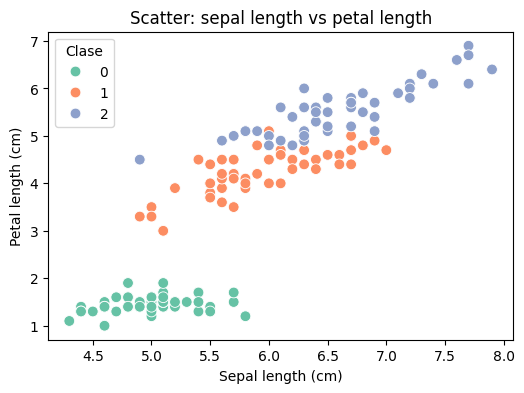

In [15]:
# Scatter simple para ver separabilidad entre clases
plt.figure(figsize=(6,4))
sns.scatterplot(
    data=df,
    x="sepal length (cm)",
    y="petal length (cm)",
    hue="target",
    palette="Set2",
    s=60
)
plt.title("Scatter: sepal length vs petal length")
plt.xlabel("Sepal length (cm)"); plt.ylabel("Petal length (cm)")
plt.legend(title="Clase")
plt.show()

Qué vemos: en Iris, las clases suelen separarse bien, sobre todo con variables de pétalo. Esto sugiere que k-NN puede funcionar muy bien.

## **+ Feature Engineering**


#### Variables:
- X (entradas): todas las características numéricas (longitud/ancho de sépalo y pétalo).

- y (salida): la clase de la flor (setosa, versicolor, virginica codificadas como 0/1/2).

k-NN usa distancias; por eso escalamos las variables para que ninguna domine por tener números más grandes.

In [16]:
# Separar variables
X = df[iris.feature_names].values  # matriz (n_samples x n_features)
y = df["target"].values            # vector de clases

# Train/Test split (estratificado para mantener proporciones por clase)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# Escalado (fit en train, transform en train y test)
scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std  = scaler.transform(X_test)

## **+ Model Selection**

Elegimos k-NN para este problema porque:
- Las clases muestran separación clara en el espacio de características (scatter).
- No asumimos una forma de frontera (k-NN no paramétrico).
- El dataset es pequeño y balanceado. k-NN es rápido y efectivo.

La elección de k: lo decidimos con validación cruzada (GridSearchCV) probando varios valores de k (1–15) y la opción weights (uniform o distance).


## **+ Model Training**

Primero buscamos el mejor k con GridSearchCV. Si quieres mantener k=3 por consigna, puedes saltarte la grilla y fijarlo.

In [17]:
# Búsqueda del mejor k y esquema de pesos
param_grid = {
    "n_neighbors": list(range(1, 16)),
    "weights": ["uniform", "distance"]  # 'distance' pondera vecinos cercanos
}

grid = GridSearchCV(
    KNeighborsClassifier(metric="minkowski", p=2),  # p=2 -> euclidiana
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)
grid.fit(X_train_std, y_train)

best_knn = grid.best_estimator_
print("Mejor modelo encontrado:", best_knn)
print("Mejor accuracy (validación cruzada):", round(grid.best_score_, 4))


Mejor modelo encontrado: KNeighborsClassifier(n_neighbors=7)
Mejor accuracy (validación cruzada): 0.9549




## **+ Prediction**

Se predicen nuevos valores con el modelo.

In [18]:
# Predicciones en el conjunto de prueba
y_pred = best_knn.predict(X_test_std)

# Función para clasificar un nuevo ejemplo (en unidades originales)
def clasificar_iris(sepal_length, sepal_width, petal_length, petal_width):
    sample = np.array([[sepal_length, sepal_width, petal_length, petal_width]])
    sample_std = scaler.transform(sample)           # usar el mismo scaler
    pred_idx = best_knn.predict(sample_std)[0]
    return pred_idx, iris.target_names[pred_idx]

# Ejemplo de uso:
clasificar_iris(5.1, 3.5, 1.4, 0.2)  # debería ser 'setosa'


(np.int64(0), np.str_('setosa'))




## **+ Model Evaluation**

##### Qué medimos:

- Matriz de confusión: aciertos/errores por clase (diagonal = aciertos).
- Accuracy: proporción de aciertos globales.
- Reporte de clasificación: precision, recall y F1 por clase (derivan de TP/FP/FN y muestran dónde hay confusiones).

Matriz de confusión:


,setosa,versicolor,virginica
setosa,12,0,0
versicolor,0,13,0
virginica,0,2,11


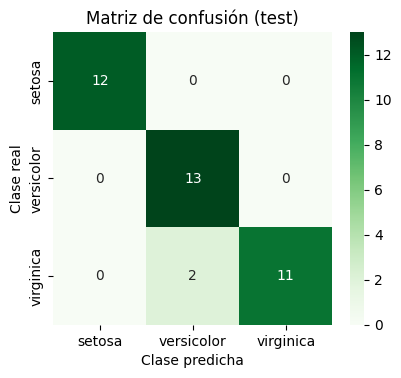

Accuracy en test: 0.9474

Reporte de clasificación:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        12
  versicolor       0.87      1.00      0.93        13
   virginica       1.00      0.85      0.92        13

    accuracy                           0.95        38
   macro avg       0.96      0.95      0.95        38
weighted avg       0.95      0.95      0.95        38



In [19]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred, labels=[0,1,2])
cm_df = pd.DataFrame(cm, index=iris.target_names, columns=iris.target_names)
print("Matriz de confusión:")
display(cm_df)

# Visualización de la matriz de confusión
plt.figure(figsize=(4.5,3.8))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Greens")
plt.title("Matriz de confusión (test)")
plt.ylabel("Clase real"); plt.xlabel("Clase predicha")
plt.show()

# Accuracy
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy en test: {acc:.4f}")

# Reporte de clasificación
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))


- Diagonal = aciertos; fuera de la diagonal = confusiones entre clases.
- Si la diagonal de la matriz tiene números altos y fuera de la diagonal son bajos, el modelo acierta con alta frecuencia.
- Accuracy cercano a 1.00 sugiere muy buen desempeño global en Iris.
- En el reporte, valores altos de precision/recall/F1 para cada clase indican que el modelo casi no confunde las especies.




## **Referencias**

- Sachdev, H. S. (2019, 27 Nov). Beginner’s Introduction to K-Nearest Neighbor(Python code).Medium

- scikit-learn developers. (s.f.). KNeighborsClassifier. Scikit-learn.

- Jain, A. (2024, 11 Jul). Everything about K Nearest Neighbour and the mathematics behind it.Medium

- Aviña Méndez, J. A. (2025, March 26). k-Nearest Neighbors (kNN). TSJZapopan.
